In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
orders = pd.read_csv("olist_orders_dataset.csv")
order_items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
Pro_Translation = pd.read_csv("product_category_name_translation.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
geolocation = pd.read_csv("olist_geolocation_dataset.csv")

In [3]:
df = orders.merge(order_items, on="order_id")

df = df.merge(products, on="product_id")

df = df.merge(customers, on="customer_id")

df = df.merge(payments, on="order_id")
df = df.merge(Pro_Translation, on="product_category_name")
df = df.merge(sellers, on="seller_id")

In [4]:
df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,sao paulo,SP,1,credit_card,1,18.12,housewares,9350,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,sao paulo,SP,3,voucher,1,2.00,housewares,9350,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,sao paulo,SP,2,voucher,1,18.59,housewares,9350,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,barreiras,BA,1,boleto,1,141.46,perfumery,31570,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,vianopolis,GO,1,credit_card,3,179.12,auto,14840,guariba,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115873,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00,1,f1d4ce8c6dd66c47bbaa8c6781c2a923,...,praia grande,SP,1,credit_card,3,195.00,baby,17602,tupa,SP
115874,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00,1,b80910977a37536adeddd63663f916ad,...,nova vicosa,BA,1,credit_card,5,271.01,home_appliances_2,8290,sao paulo,SP
115875,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,1,d1c427060a0f73f6b889a5c7c61f2ac4,...,japuiba,RJ,1,credit_card,4,441.16,computers_accessories,37175,ilicinea,MG
115876,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00,2,d1c427060a0f73f6b889a5c7c61f2ac4,...,japuiba,RJ,1,credit_card,4,441.16,computers_accessories,37175,ilicinea,MG


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115878 entries, 0 to 115877
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       115878 non-null  object 
 1   customer_id                    115878 non-null  object 
 2   order_status                   115878 non-null  object 
 3   order_purchase_timestamp       115878 non-null  object 
 4   order_approved_at              115864 non-null  object 
 5   order_delivered_carrier_date   114673 non-null  object 
 6   order_delivered_customer_date  113383 non-null  object 
 7   order_estimated_delivery_date  115878 non-null  object 
 8   order_item_id                  115878 non-null  int64  
 9   product_id                     115878 non-null  object 
 10  seller_id                      115878 non-null  object 
 11  shipping_limit_date            115878 non-null  object 
 12  price                         

In [6]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["order_delivered_carrier_date"] = pd.to_datetime(df["order_delivered_carrier_date"])
df["order_delivered_customer_date"]= pd.to_datetime(df["order_delivered_customer_date"])
df["order_estimated_delivery_date"]= pd.to_datetime(df["order_estimated_delivery_date"])
df["shipping_limit_date"]= pd.to_datetime(df["shipping_limit_date"])
df["order_approved_at"]= pd.to_datetime(df["order_approved_at"])

monthly_sales = df.groupby(df["order_purchase_timestamp"].dt.month)["price"].sum()

In [7]:
df.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
order_item_id                             int64
product_id                               object
seller_id                                object
shipping_limit_date              datetime64[ns]
price                                   float64
freight_value                           float64
product_category_name                    object
product_name_lenght                     float64
product_description_lenght              float64
product_photos_qty                      float64
product_weight_g                        float64
product_length_cm                       float64
product_height_cm                       

In [8]:
top_products = df.groupby("product_id")["price"].sum().sort_values(ascending=False).head(10)

In [9]:
top_products_name = df.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False).head(10)

In [10]:
top_products_name

product_category_name_english
health_beauty            1297355.80
watches_gifts            1253143.30
bed_bath_table           1092551.02
sports_leisure           1023996.34
computers_accessories     942277.57
furniture_decor           765093.89
housewares                666587.00
cool_stuff                662309.49
auto                      616752.51
garden_tools              518217.54
Name: price, dtype: float64

In [11]:
# total_price= df['price'].sum()
# total_price

## Data cleaning

In [12]:
df.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    2495
order_delivered_carrier_date     1205
order_approved_at                  14
product_height_cm                   1
product_width_cm                    1
product_weight_g                    1
product_length_cm                   1
order_id                            0
customer_id                         0
order_purchase_timestamp            0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
order_status                        0
order_estimated_delivery_date       0
order_item_id                       0
product_id                          0
product_photos_qty                  0
product_description_lenght          0
product_name_lenght                 0
product_category_name               0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
payment_sequ

### Handle Undelivered Orders

In [13]:
df[df.isnull().any(axis=1)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
50,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaT,2018-06-28,1,c50ca07e9e4db9ea5011f06802c0aea0,...,jundiai,SP,1,boleto,1,22.36,health_beauty,11701,praia grande,SP
124,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaT,NaT,2018-08-21,1,1522589c64efd46731d3522568e5bc83,...,santo amaro da imperatriz,SC,1,boleto,1,50.35,christmas_supplies,3644,sao paulo,SP
153,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaT,NaT,2017-10-03,1,61d52f4882421048afd530db53d6f230,...,sao paulo,SP,1,credit_card,2,138.28,perfumery,19023,presidente prudente,SP
190,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaT,2018-02-07,1,ee0c1cf2fbeae95205b4aa506f1469f0,...,paracatu,MG,1,boleto,1,69.12,perfumery,9015,santo andre,SP
198,36530871a5e80138db53bcfd8a104d90,4dafe3c841d2d6cc8a8b6d25b35704b9,shipped,2017-05-09 11:48:37,2017-05-11 11:45:14,2017-05-11 13:21:47,NaT,2017-06-08,1,ba4bfbf74dbe7ab37e263b9326da0523,...,camaragibe,PE,1,credit_card,6,63.79,sports_leisure,13324,salto,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115527,aea0db338150b526dde24f6fd953a5ed,379a02efdc6a56bd27f99b95fc2f6c06,processing,2017-12-26 21:56:13,2017-12-26 22:05:26,NaT,NaT,2018-01-26,1,aa428a8e4d587520f90d37a08030a812,...,aquidauana,MS,1,credit_card,2,113.34,toys,3470,sao paulo,SP
115536,6560fb10610771449cb0463c5ba12199,0d07d0a588caf93cc66b7a8aff86d2fe,canceled,2017-10-01 22:26:25,2017-10-01 22:35:22,NaT,NaT,2017-10-27,1,dc2410804cf782c5d87dbcd201b74e9b,...,curitiba,PR,1,credit_card,3,333.62,computers_accessories,14092,ribeirao preto,SP
115537,6560fb10610771449cb0463c5ba12199,0d07d0a588caf93cc66b7a8aff86d2fe,canceled,2017-10-01 22:26:25,2017-10-01 22:35:22,NaT,NaT,2017-10-27,2,dc2410804cf782c5d87dbcd201b74e9b,...,curitiba,PR,1,credit_card,3,333.62,computers_accessories,14092,ribeirao preto,SP
115579,636cdd02667dc8d76d9296bf20a6890a,c162256b133c76f79181ce61d66545db,shipped,2018-02-17 14:31:22,2018-02-20 07:11:31,2018-02-20 19:18:58,NaT,2018-03-14,1,52c80cedd4e90108bf4fa6a206ef6b03,...,taubate,SP,1,boleto,1,224.71,garden_tools,37175,ilicinea,MG


In [14]:
df["order_status"].value_counts()

order_status
delivered      113384
shipped          1214
canceled          549
processing        362
invoiced          359
unavailable         7
approved            3
Name: count, dtype: int64

In [15]:
df['order_delivered_customer_date'].isnull().value_counts()

order_delivered_customer_date
False    113383
True       2495
Name: count, dtype: int64

In [16]:

df[df['order_delivered_customer_date'].isnull()]['order_status'].value_counts()

order_status
shipped        1214
canceled        542
processing      362
invoiced        359
delivered         8
unavailable       7
approved          3
Name: count, dtype: int64

In [17]:
df[df["order_approved_at"].isnull()]["order_status"].value_counts()

order_status
delivered    14
Name: count, dtype: int64

In [18]:
df[df['order_delivered_customer_date'].notnull()]['order_status'].value_counts()

order_status
delivered    113376
canceled          7
Name: count, dtype: int64

In [19]:
df_full= df.copy()

In [20]:
# Keep only delivered orders + non-delivered with delivery date (completed cases)
mask_keep = (df['order_status'] == 'delivered') | df['order_delivered_customer_date'].notnull()
df_clean = df[mask_keep].copy()

# Verify
print(df_clean['order_status'].value_counts())
# Expected: delivered: 113376 (113384-8), shipped:8, canceled:7?, etc. + any others with date


order_status
delivered    113384
canceled          7
Name: count, dtype: int64


In [21]:
# For delivery analysis, remove them.
df = df[df['order_status'] == 'delivered']

In [22]:
df["order_delivered_customer_date"].notnull().value_counts()

order_delivered_customer_date
True     113376
False         8
Name: count, dtype: int64

In [23]:
df[df['order_delivered_customer_date'].isnull()]['order_status'].value_counts()

order_status
delivered    8
Name: count, dtype: int64

In [24]:
df[df.isnull().any(axis=1)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
3481,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18,1,a50acd33ba7a8da8e9db65094fa990a4,...,cerquilho,SP,1,credit_card,3,134.83,auto,7112,guarulhos,SP
6125,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaT,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17,1,0e20a07ca1714df21f9b07ca3bf7c682,...,cotia,SP,1,boleto,1,349.01,small_appliances,14882,jaboticabal,SP
19220,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaT,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21,1,2c2b6a28924791234bd386bddb17512e,...,novo hamburgo,RS,1,boleto,1,396.86,construction_tools_safety,88090,florianopolis,SC
23992,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16,1,2167c8f6252667c0eb9edd51520706a1,...,quadra,SP,1,debit_card,1,354.24,industry_commerce_and_business,18130,sao roque,SP
26360,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaT,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31,1,c6dd917a0be2a704582055949915ab32,...,caninde,CE,1,boleto,1,106.81,cool_stuff,3426,sao paulo,SP
26939,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaT,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20,1,c6dd917a0be2a704582055949915ab32,...,macae,RJ,1,boleto,1,95.76,cool_stuff,3426,sao paulo,SP
31256,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaT,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01,1,5ab02ca028398131a5ae91401eb49788,...,santos,SP,1,boleto,1,54.51,sports_leisure,83323,pinhais,PR
44682,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaT,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27,1,cae2e38942c8489d9d7a87a3f525c06b,...,sao paulo,SP,1,boleto,1,163.43,furniture_decor,14940,ibitinga,SP
44740,85f8ad45e067abd694b627859fa57453,1d088dea8732788ec35dd4ee6dd76112,delivered,2017-01-29 21:40:02,2017-01-30 22:32:20,2017-02-02 05:04:58,2017-02-07 10:46:00,2017-03-08,1,09ff539a621711667c43eba6a3bd8466,...,porto alegre,RS,1,credit_card,10,1961.00,baby,86020,londrina,PR
45897,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaT,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22,1,02a79d79e818ad0be36cfc843a6af7ad,...,varzea paulista,SP,1,boleto,1,39.95,sports_leisure,3028,sao paulo,SP


In [25]:
(24 / len(df)) * 100

0.02116700769067946

### Handle Missing Delivery Dates

#### After filtering delivered orders, check again.



In [26]:
df.isnull().sum().sort_values(ascending=False)

order_approved_at                14
order_delivered_customer_date     8
order_delivered_carrier_date      2
product_height_cm                 1
product_width_cm                  1
product_weight_g                  1
product_length_cm                 1
order_id                          0
customer_id                       0
order_purchase_timestamp          0
seller_id                         0
shipping_limit_date               0
price                             0
freight_value                     0
order_status                      0
order_estimated_delivery_date     0
order_item_id                     0
product_id                        0
product_photos_qty                0
product_description_lenght        0
product_name_lenght               0
product_category_name             0
customer_unique_id                0
customer_zip_code_prefix          0
customer_city                     0
customer_state                    0
payment_sequential                0
payment_type                

### Handle "order_approved_at"

#### Only 14 missing rows, so just fill with purchase timestamp.


In [27]:

df['order_approved_at'].fillna(df['order_purchase_timestamp'], inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_16580\225691971.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['order_approved_at'].fillna(df['order_purchase_timestamp'], inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_16580\225691971.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['order_approved_at'].fillna(df['order_purch

### Handle Product Dimension Missing Values

#### Only 1 missing value each, so fill with median.

In [28]:
df['product_height_cm'].fillna(df['product_height_cm'].median(), inplace=True)

df['product_width_cm'].fillna(df['product_width_cm'].median(), inplace=True)

df['product_weight_g'].fillna(df['product_weight_g'].median(), inplace=True)

df['product_length_cm'].fillna(df['product_length_cm'].median(), inplace=True)

C:\Users\USER\AppData\Local\Temp\ipykernel_16580\4119560073.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['product_height_cm'].fillna(df['product_height_cm'].median(), inplace=True)
C:\Users\USER\AppData\Local\Temp\ipykernel_16580\4119560073.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['product_height_cm'].fillna(df['product

In [29]:
# Remove Duplicates 
df = df.drop_duplicates()


In [30]:
df.isnull().sum().sort_values(ascending=False)

order_delivered_customer_date    8
order_delivered_carrier_date     2
customer_id                      0
order_id                         0
order_purchase_timestamp         0
order_status                     0
order_approved_at                0
order_estimated_delivery_date    0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
payment_sequential               0
payment_type                     0
payment_installments

In [31]:
df[df.isnull().any(axis=1)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state
3481,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaT,2017-12-18,1,a50acd33ba7a8da8e9db65094fa990a4,...,cerquilho,SP,1,credit_card,3,134.83,auto,7112,guarulhos,SP
23992,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaT,2018-07-16,1,2167c8f6252667c0eb9edd51520706a1,...,quadra,SP,1,debit_card,1,354.24,industry_commerce_and_business,18130,sao roque,SP
51118,2ebdfc4f15f23b91474edf87475f108e,29f0540231702fda0cfdee0a310f11aa,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,2018-07-03 13:57:00,NaT,2018-07-30,1,e7d5464b94c9a5963f7c686fc80145ad,...,pindamonhangaba,SP,1,credit_card,3,158.07,watches_gifts,36407,conselheiro lafaiete,MG
85198,2aa91108853cecb43c84a5dc5b277475,afeb16c7f46396c0ed54acb45ccaaa40,delivered,2017-09-29 08:52:58,2017-09-29 09:07:16,NaT,2017-11-20 19:44:47,2017-11-14,1,44c2baf621113fa7ac95fa06b4afbc68,...,indaiatuba,SP,1,credit_card,1,193.98,furniture_decor,87240,terra boa,PR
92219,e69f75a717d64fc5ecdfae42b2e8e086,cfda40ca8dd0a5d486a9635b611b398a,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,2018-07-03 13:57:00,NaT,2018-07-30,1,e7d5464b94c9a5963f7c686fc80145ad,...,sumare,SP,1,credit_card,1,158.07,watches_gifts,36407,conselheiro lafaiete,MG
96408,0d3268bad9b086af767785e3f0fc0133,4f1d63d35fb7c8999853b2699f5c7649,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,2018-07-03 09:28:00,NaT,2018-07-24,1,ec165cd31c50585786ffda6feff5d0a6,...,sao carlos,SP,1,credit_card,4,204.62,toys,1552,sao paulo,SP
107902,2d858f451373b04fb5c984a1cc2defaf,e08caf668d499a6d643dafd7c5cc498a,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,NaT,2017-06-23,1,30b5b5635a79548a48d04162d971848f,...,porto alegre,RS,1,credit_card,4,194.00,sports_leisure,5319,sao paulo,SP
113739,ab7c89dc1bf4a1ead9d6ec1ec8968a84,dd1b84a7286eb4524d52af4256c0ba24,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,2018-06-12 14:10:00,NaT,2018-06-26,1,a2a7efc985315e86d4f0f705701b342b,...,guarulhos,SP,1,credit_card,5,120.12,computers_accessories,8260,sao paulo,SP
114184,20edc82cf5400ce95e1afacc25798b31,28c37425f1127d887d7337f284080a0f,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,2018-07-03 19:26:00,NaT,2018-07-19,1,55bfa0307d7a46bed72c492259921231,...,ribeirao pires,SP,1,credit_card,1,54.97,books_general_interest,13033,campinas,SP


In [32]:
df= df.dropna()

In [33]:
df[df.isnull().any(axis=1)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,customer_city,customer_state,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state


In [34]:
# df.to_excel("Cleaned_Dataset1.xlsx", index= False)

## Exploratiory Data Analysis(EDA)

### Cleaned Dataset overview(Understanding the direct structure of data)

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113375 entries, 0 to 115877
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       113375 non-null  object        
 1   customer_id                    113375 non-null  object        
 2   order_status                   113375 non-null  object        
 3   order_purchase_timestamp       113375 non-null  datetime64[ns]
 4   order_approved_at              113375 non-null  datetime64[ns]
 5   order_delivered_carrier_date   113375 non-null  datetime64[ns]
 6   order_delivered_customer_date  113375 non-null  datetime64[ns]
 7   order_estimated_delivery_date  113375 non-null  datetime64[ns]
 8   order_item_id                  113375 non-null  int64         
 9   product_id                     113375 non-null  object        
 10  seller_id                      113375 non-null  object        
 11  shipp

In [36]:
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,shipping_limit_date,price,freight_value,product_name_lenght,...,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,customer_zip_code_prefix,payment_sequential,payment_installments,payment_value,seller_zip_code_prefix
count,113375,113375,113375,113375,113375,113375.000000,113375,113375.000000,113375.000000,113375.000000,...,113375.000000,113375.000000,113375.000000,113375.000000,113375.000000,113375.000000,113375.000000,113375.000000,113375.000000,113375.000000
mean,2018-01-01 13:34:26.825402368,2018-01-02 00:00:25.091924736,2018-01-04 20:13:55.135691264,2018-01-14 01:06:22.869768448,2018-01-25 09:34:59.796251392,1.196842,2018-01-08 04:02:39.525856768,120.178240,20.024523,48.801764,...,2.209155,2110.658046,30.283916,16.616944,23.099881,35083.147757,1.089940,2.942386,172.237100,24514.122161
min,2016-10-03 09:44:50,2016-10-04 09:43:32,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-27 00:00:00,1.000000,2016-10-08 10:34:01,0.850000,0.000000,5.000000,...,1.000000,0.000000,7.000000,2.000000,6.000000,1003.000000,1.000000,0.000000,0.000000,1001.000000
25%,2017-09-13 18:47:31,2017-09-14 02:55:32,2017-09-15 21:44:53.500000,2017-09-25 19:42:27,2017-10-05 00:00:00,1.000000,2017-09-20 19:34:47,39.900000,13.080000,42.000000,...,1.000000,300.000000,18.000000,8.000000,15.000000,11320.000000,1.000000,1.000000,61.000000,6429.000000
50%,2018-01-20 15:36:23,2018-01-20 21:41:17,2018-01-24 13:06:49,2018-02-02 16:12:53,2018-02-16 00:00:00,1.000000,2018-01-26 14:38:22,74.900000,16.320000,52.000000,...,1.000000,700.000000,25.000000,13.000000,20.000000,24330.000000,1.000000,2.000000,108.120000,13660.000000
75%,2018-05-05 17:27:17.500000,2018-05-06 07:30:14,2018-05-08 14:33:30,2018-05-15 21:20:15,2018-05-28 00:00:00,1.000000,2018-05-10 21:13:39,133.820000,21.200000,57.000000,...,3.000000,1800.000000,38.000000,20.000000,30.000000,58780.000000,1.000000,4.000000,189.370000,28495.000000
max,2018-08-29 15:00:37,2018-08-29 15:10:26,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,21.000000,2020-04-09 22:35:08,6735.000000,409.680000,76.000000,...,20.000000,40425.000000,105.000000,105.000000,118.000000,99980.000000,26.000000,24.000000,13664.080000,99730.000000
std,NaN,NaN,NaN,NaN,NaN,0.701302,NaN,182.790244,15.752803,10.017997,...,1.720235,3770.844822,16.161831,13.448266,11.741064,29845.886135,0.682096,2.777893,266.621369,27639.402300


In [37]:
df.nunique()

order_id                         95117
customer_id                      95117
order_status                         1
order_purchase_timestamp         94613
order_approved_at                87120
order_delivered_carrier_date     78915
order_delivered_customer_date    94329
order_estimated_delivery_date      444
order_item_id                       21
product_id                       31618
seller_id                         2912
shipping_limit_date              90120
price                             5790
freight_value                     6902
product_category_name               71
product_name_lenght                 65
product_description_lenght        2944
product_photos_qty                  19
product_weight_g                  2168
product_length_cm                   99
product_height_cm                  102
product_width_cm                    94
customer_unique_id               92069
customer_zip_code_prefix         14844
customer_city                     4073
customer_state           

In [38]:
df.shape

(113375, 34)

## insight
### The cleaned e-commerce dataset contains 113,375 transaction records and 34 variables describing orders, products, customers, sellers, and payments.

### The platform processed 95,117 orders from 95,117 unique customers, purchasing 31,618 different products sold by 2,912 sellers.

### Products are organized into 71 categories, and customers come from 27 Brazilian states and more than 4,000 cities, indicating nationwide coverage.

### The dataset also includes multiple datetime features that allow detailed analysis of sales trends and delivery performance.

## Order Status Analysis
#### Goal: Understand Order Distribution

### Questions

#### How many orders are delivered?

#### Are there canceled or unavailable orders?

In [39]:
df["order_status"].value_counts()

order_status
delivered    113375
Name: count, dtype: int64

### Feature Engineering

In [40]:

# Delivery time
df['delivery_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

### Drop these rows which still has null values

In [41]:
# df = df.dropna(subset=[
    
#     'order_delivered_customer_date',
#     'order_delivered_carrier_date',
#     'order_approved_at',
#     'product_weight_g',
#     'product_height_cm'
# ])

In [42]:
df.shape

(113375, 35)

# Extract time features

In [43]:

df['year'] = df['order_purchase_timestamp'].dt.year
df['month'] = df['order_purchase_timestamp'].dt.month_name()
df['day'] = df['order_purchase_timestamp'].dt.day
df['weekday'] = df['order_purchase_timestamp'].dt.day_name()
df['month_year'] = df['order_purchase_timestamp'].dt.to_period('M')

In [44]:
# delivery time 
df['delivery_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

### For KPI Calculation

In [45]:
# total order value
df['total_price'] = df['price'] + df['freight_value']

In [46]:
# Calculate revenue
total_revenue= df['total_price'].sum()
print(f"Revenue= {total_revenue}")

Revenue= 15895488.16


In [47]:
# Total Orders
total_orders= df['order_id'].nunique()
print(f"Orders= {total_orders}")

Orders= 95117


In [48]:
# Total Customers
uni_customers= df['customer_unique_id'].nunique()
print(f"Customers= {uni_customers}")

Customers= 92069


In [49]:
# total products
Products= df["product_id"].nunique()
print(f"Products= {Products}")

Products= 31618


In [50]:
# Total Sellers
Sellers= df['seller_id'].nunique()
print(f"Selers= {Sellers}")

Selers= 2912


In [51]:
# Average Order Value
Average_order_value= df.groupby('order_id')['total_price'].sum().mean()
print(f"Average order value = {Average_order_value}")

Average order value = 167.11511254560176


### Sales Analysis

In [52]:
# 1. Define the correct chronological order
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June', 
    'July', 'August', 'September', 'October', 'November', 'December'
]

# 2. Extract the month name as usual
df['month'] = df['order_purchase_timestamp'].dt.month_name()

# 3. this is a Category with a specific order
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)


In [53]:

# Monthly Revenue
monthly_sales = df.groupby('month')['total_price'].sum()
monthly_sales

C:\Users\USER\AppData\Local\Temp\ipykernel_16580\1578912970.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  monthly_sales = df.groupby('month')['total_price'].sum()


month
January      1230102.81
February     1266112.31
March        1581203.95
April        1564464.22
May          1759610.03
June         1568152.66
July         1658898.63
August       1684228.64
September     735075.49
October       813211.02
November     1178079.98
December      856348.42
Name: total_price, dtype: float64

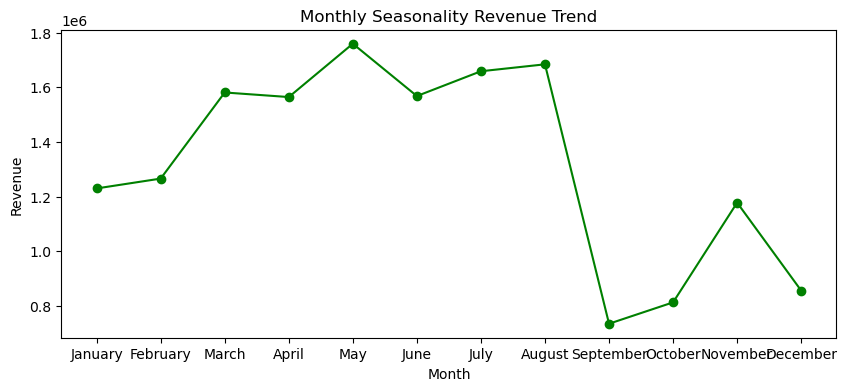

In [54]:
# Visualization:

import matplotlib.pyplot as plt

# Monthly Seasonality Analysis
plt.figure(figsize= (10,4))
plt.plot(monthly_sales.index, monthly_sales.values,marker='o', color= 'g')
plt.title("Monthly Seasonality Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [55]:
# Top Product Categories
top_categories = (
    df.groupby('product_category_name_english')['total_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_categories

product_category_name_english
health_beauty            1456026.83
watches_gifts            1315013.93
bed_bath_table           1292579.23
sports_leisure           1159732.82
computers_accessories    1068666.04
furniture_decor           922930.17
housewares                798858.27
cool_stuff                719603.22
auto                      696377.68
garden_tools              593832.05
Name: total_price, dtype: float64

In [56]:
# Best Sellers
top_sellers = (
    df.groupby('seller_id')['total_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_sellers

seller_id
4869f7a5dfa277a7dca6462dcf3b52b2    255991.88
53243585a1d6dc2643021fd1853d8905    253822.62
7c67e1448b00f6e969d365cea6b010ab    250819.57
4a3ca9315b744ce9f8e9374361493884    246207.98
fa1c13f2614d7b5c4749cbc52fecda94    211203.59
da8622b14eb17ae2831f4ac5b9dab84a    194722.21
7e93a43ef30c4f03f38b393420bc753a    178695.40
1025f0e2d44d7041d6cf58b6550e0bfa    175910.19
7a67c85e85bb2ce8582c35f2203ad736    169643.39
955fee9216a65b617aa5c0531780ce60    159187.33
Name: total_price, dtype: float64

In [57]:
# Sales by State
state_sales = df.groupby('customer_state')['total_price'].sum()


In [58]:
# Payment Method Analysis
payment_analysis = df['payment_type'].value_counts()

In [59]:
# Delivery Performance
df['delivery_days'].describe()

count    113375.000000
mean         12.015109
std           9.450103
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_days, dtype: float64

In [60]:
### Customer Behavior
# Repeat customers
repeat_customers = df.groupby('customer_unique_id')['order_id'].nunique()

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

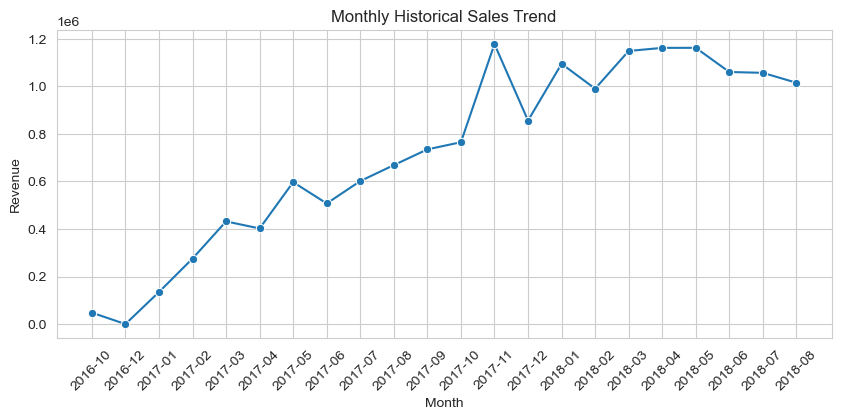

In [62]:
# Monthly Historical Revenue Growth Trend
df['month_year'] = df['order_purchase_timestamp'].dt.to_period('M')

monthly_sales = df.groupby('month_year')['total_price'].sum().reset_index()

monthly_sales['month_year'] = monthly_sales['month_year'].astype(str)

plt.figure(figsize=(10,4))
sns.lineplot(data=monthly_sales, x='month_year', y='total_price', marker='o')

plt.xticks(rotation=45)
plt.title("Monthly Historical Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

### Insights:
### Sales show clear growth trend
### Peak observed in Nov–Jan (holiday season effect)

## top Product Categories

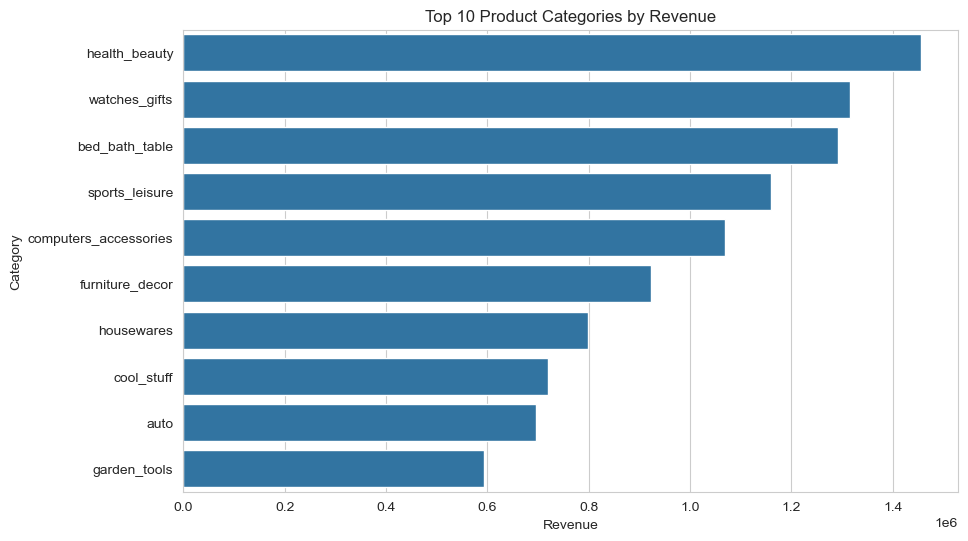

In [63]:

top_categories = (
    df.groupby('product_category_name_english')['total_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=top_categories.values, y=top_categories.index)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.show()

### Insight:
### The revenue distribution across product categories shows a strong concentration in a few key segments, particularly health & beauty, watches & gifts, and home-related products. These categories act as primary revenue drivers, indicating customer preference for lifestyle and personal-use products. Lower-performing categories present opportunities for growth through targeted marketing and strategic positioning.

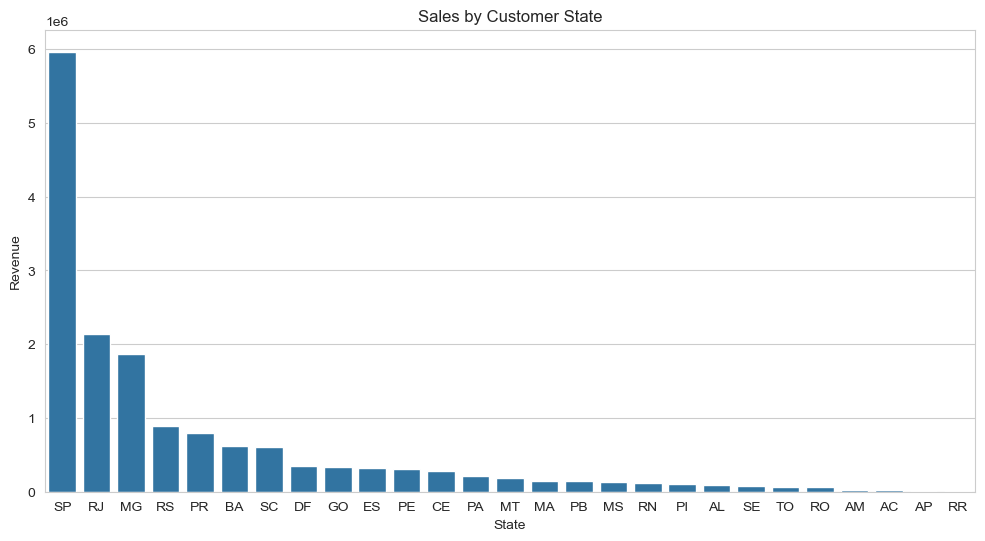

In [64]:
# Sales by State
state_sales = df.groupby('customer_state')['total_price'].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(x=state_sales.index, y=state_sales.values)

plt.title("Sales by Customer State")
plt.xlabel("State")
plt.ylabel("Revenue")
plt.show()

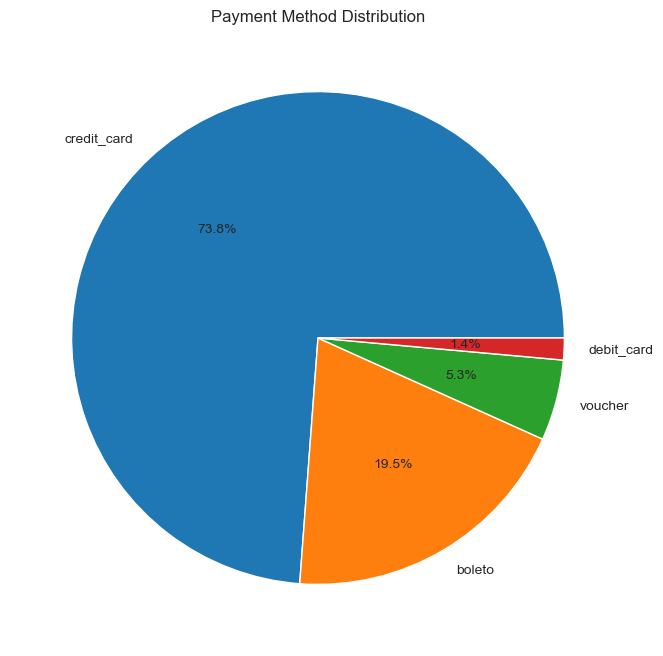

In [65]:
# Payment Method Distribution
payment_counts = df['payment_type'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%')

plt.title("Payment Method Distribution")
plt.show()

In [66]:
# Delivery Time Distribution

# First create delivery days.

df['delivery_days'] = (
    df['order_delivered_customer_date'] -
    df['order_purchase_timestamp']
).dt.days

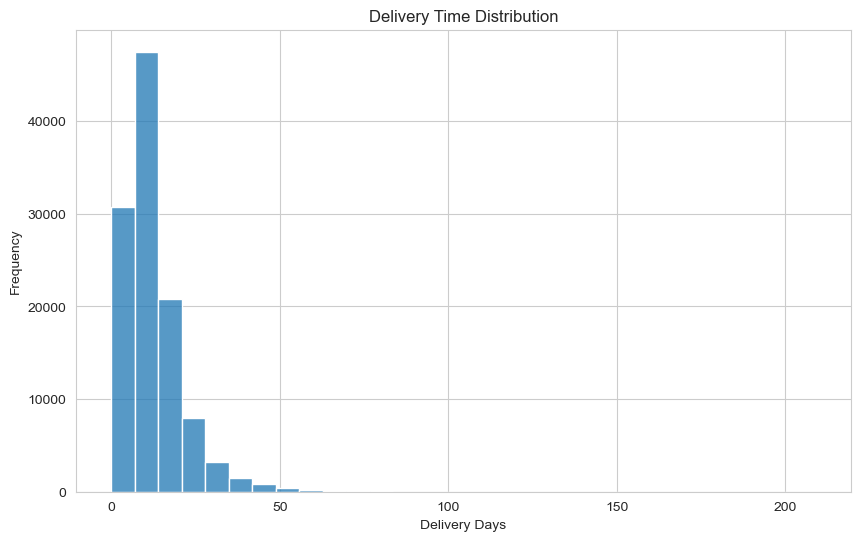

In [67]:
# Then plot:

plt.figure(figsize=(10,6))
sns.histplot(df['delivery_days'], bins=30)

plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Frequency")
plt.show()

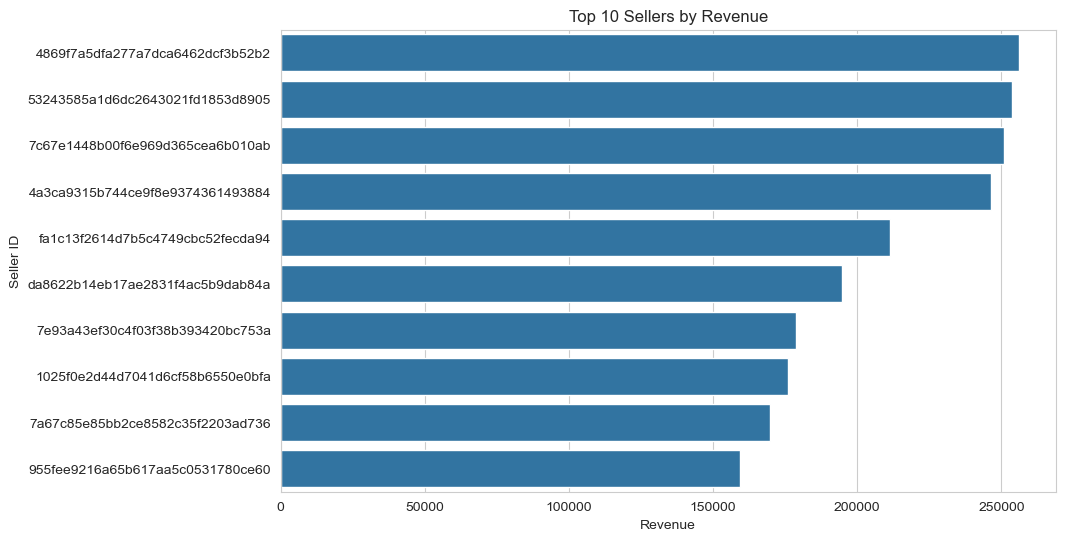

In [68]:
# Top Sellers
top_sellers = (
    df.groupby('seller_id')['total_price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=top_sellers.values, y=top_sellers.index)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller ID")
plt.show()

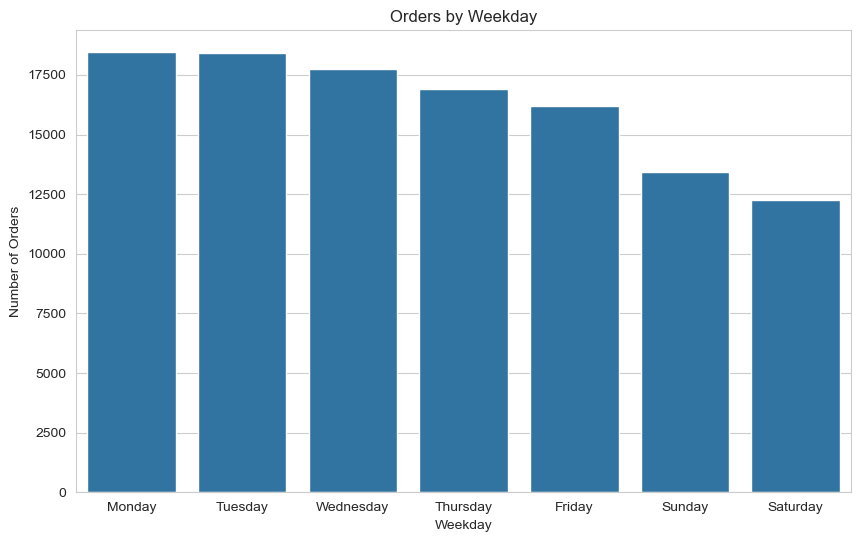

In [69]:
### Orders by Weekday

# Create weekday column:

df['weekday'] = df['order_purchase_timestamp'].dt.day_name()

# Then chart:

weekday_orders = df['weekday'].value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=weekday_orders.index, y=weekday_orders.values)

plt.title("Orders by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Number of Orders")
plt.show()

In [70]:
df[df.isnull().any(axis=1)]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,seller_zip_code_prefix,seller_city,seller_state,delivery_days,year,month,day,weekday,month_year,total_price


In [71]:
# df.to_excel("Cleaned_Dataset_Final1.xlsx", index= False)

In [72]:
cols_to_drop = [
    'customer_id',
    'product_category_name',
    'seller_zip_code_prefix',
    'customer_zip_code_prefix',
    'order_item_id',
    'shipping_limit_date',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_estimated_delivery_date'
]

df_final = df.drop(columns=cols_to_drop)

### Irrelevant and redundant columns were removed to optimize the dataset for analysis and visualization. Only features relevant to business insights and dashboard reporting were retained.

In [73]:
cols_to_drop1= [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

df_final1=df_final.drop(columns= cols_to_drop1)

In [74]:
df_final1[df_final.isnull().any(axis=1)]

,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,product_id,seller_id,price,freight_value,product_name_lenght,product_description_lenght,...,product_category_name_english,seller_city,seller_state,delivery_days,year,month,day,weekday,month_year,total_price


In [75]:
#!pip install openpyxl

In [76]:
# df_final1.to_excel("final_cleaned_dataset.xlsx", index=False)